# J.P. Morgan Quantitative Research: Natural Gas Pricing & Storage Contract Valuation

**Author:** Risalat Masrafi  
**Institution:** Singapore Polytechnic  
**Date:** February 2026  

---

## Project Purpose
The objective of this project is to develop an end-to-end quantitative pricing and valuation engine for the J.P. Morgan commodities trading desk. The project is divided into two core mandates:
1. **Predictive Pricing Model:** Deve|lop a robust time-series model capable of forecasting natural gas prices for any specified historical or future date, capturing underlying market trends and seasonal volatility.
2. **Contract Valuation Engine:** Build a financial calculator that utilizes these price forecasts to determine the Net Present Value (NPV) of physical natural gas storage contracts, enabling the desk to optimize risk margins and quickly assess trade profitability.

## Workflow & Methodology

### Task 1: Predictive Pricing Model
1. **Data Import & Preprocessing:** Cleaned the raw end-of-month snapshot data, standardized the temporal index, and conducted Exploratory Data Analysis (EDA) to visualize historical trends and seasonal cycles.
2. **Model Selection & Tuning:** Evaluated time series architectures and optimized a **Holt-Winters Exponential Smoothing** model (Multiplicative Trend, Additive Seasonality) to capture physical market dynamics.
3. **Validation & Testing:** Validated the forecasting architecture using a strict Train/Validation split to ensure generalization without overfitting, tracked via RMSE and MAPE metrics.
4. **Interpolation & Extrapolation:** Built a continuous pricing curve by extrapolating 12 months into the future and utilizing linear interpolation to resolve mid-month daily price estimates.
5. **Interactive Price Oracle:** Encapsulated the forecasting model into a dynamic Python function (`get_price_estimate`) with a 95% Confidence Interval to assist risk managers in pricing uncertainty.

### Task 2: Storage Contract Valuation Engine
1. **Model Integration:** Engineered a Net Present Value (NPV) calculator that dynamically fetches price estimates from the Task 1 model to evaluate profitable seasonal trade spreads.
2. **Risk & Cost Engineering:** Factored in the physical constraints of the storage facility (maximum total volume) and the financial cost of carry (monthly storage rental fees).
3. **Scenario Testing:** Executed test scenarios to verify the logic and output the final intrinsic dollar value of proposed derivative contracts.


# Task 1

## Importing Dependencies and Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")



# Load the dataset
data = pd.read_csv("JPMNat_Gas.csv")
data.head(10)


,Dates,Prices
0,10/31/20,10.10
1,11/30/20,10.30
2,12/31/20,11.00
3,1/31/21,10.90
4,2/28/21,10.90
5,3/31/21,10.90
6,4/30/21,10.40
7,5/31/21,9.84
8,6/30/21,10.00
9,7/31/21,10.10


In [5]:
print(data.info())
print(data.describe())
print(data.isnull().sum())
print(data.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Dates   48 non-null     object 
 1   Prices  48 non-null     float64
dtypes: float64(1), object(1)
memory usage: 900.0+ bytes
None
          Prices
count  48.000000
mean   11.207083
std     0.757897
min     9.840000
25%    10.650000
50%    11.300000
75%    11.625000
max    12.800000
Dates     0
Prices    0
dtype: int64
0


## Data Preprocessing

In [6]:
data['DATE'] = pd.to_datetime(data['Dates'], format='%m/%d/%y', errors='coerce')
data['DATE'] = data['DATE'].dt.to_period('M').dt.to_timestamp()

# Set index and drop the old messy 'Dates' column
data.set_index('DATE', inplace=True)
data.drop(columns=['Dates'], inplace=True)

# Set frequency
data = data.asfreq('MS')

data.head()

,Prices
DATE,
2020-10-01,10.1
2020-11-01,10.3
2020-12-01,11.0
2021-01-01,10.9
2021-02-01,10.9


### Data Preprocessing: Time Series Indexing

Before building any forecasting models, the raw date strings must be converted into a standardized, mathematically readable time series format. This step ensures that the predictive algorithms correctly interpret the chronological spacing of the price data.

**Transformation Steps:**
* **Datetime Conversion:** Parsed the raw `Dates` column from a string format (`MM/DD/YY`) into proper Pandas datetime objects, coercing any errors into null values.
* **Monthly Normalization:** Standardized all timestamps to the first day of their respective month (`to_period('M')` -> `to_timestamp()`) to create a perfectly uniform temporal grid.
* **Index Assignment:** Promoted the cleaned `DATE` column to the DataFrame's official index and dropped the redundant original column to keep the dataset lightweight.
* **Frequency Setting:** Explicitly defined the time series frequency as Month Start (`MS`).

## Exploratory Data Analysis

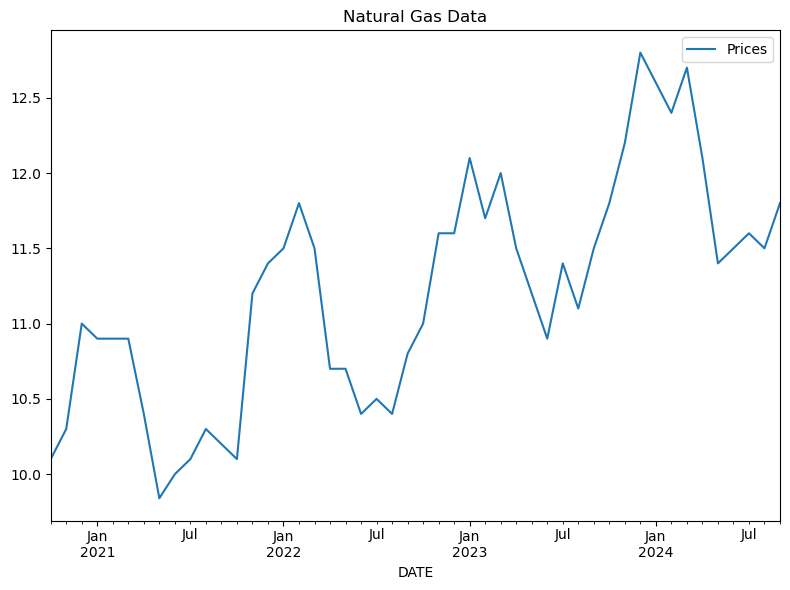

In [7]:
data.plot(figsize=(8, 6), title="Natural Gas Data")
plt.tight_layout()
plt.show()

### Exploratory Data Analysis: Initial Visualization

Before applying any statistical transformations or forecasting models, the first step is to visualize the raw historical data. This initial plot provides a high-level overview of the Natural Gas price movements over the given timeline.

**Objectives of this visualization:**
* **Identify Trend:** Observe whether the baseline price is generally increasing, decreasing, or remaining stationary over the multi-year period.
* **Spot Seasonality:** Look for recurring cyclical patterns (e.g., annual winter peaks and summer troughs) that would justify using seasonal forecasting models.
* **Detect Anomalies:** Quickly identify any extreme outliers, missing data gaps, or sudden market shocks in the historical record.

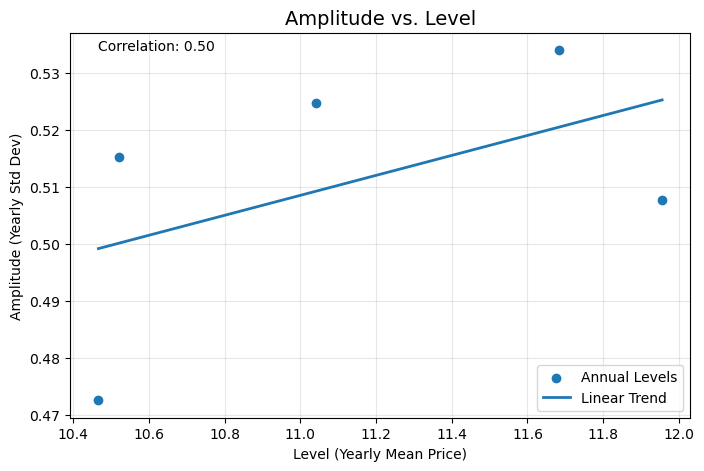

In [8]:
# 1. Prepare data (Yearly Mean and Std Dev)
yearly_stats = data['Prices'].resample('Y').agg(['mean', 'std']).dropna()
x = yearly_stats['mean']
y = yearly_stats['std']

# 2. Calculate the simple trendline (degree 1 = straight line)
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

# 3. Create the plot
plt.figure(figsize=(8, 5))

# Scatter points
plt.scatter(x, y,label='Annual Levels')

# Simple line of best fit
plt.plot(x, p(x),linewidth=2, label='Linear Trend')

plt.text(x.min(), y.max(), f'Correlation: {x.corr(y):.2f}', fontsize=10)

# Labels and Title
plt.title('Amplitude vs. Level', fontsize=14)
plt.xlabel('Level (Yearly Mean Price)')
plt.ylabel('Amplitude (Yearly Std Dev)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Diagnostic: Amplitude vs. Level Analysis

To determine the correct seasonal model for the natural gas pricing extrapolation, I analyzed the relationship between the series' rolling level (trend) and its rolling amplitude (seasonal volatility). 

**Results:**
* **Pearson Correlation ($r$):** $0.5$

**Interpretation & Modeling Strategy:**
The moderate positive correlation ($r = 0.5$) indicates that the magnitude of the seasonal swings increases as the baseline price of natural gas rises. This is a classic signature of **Multiplicative Seasonality**. 

Because an additive model assumes constant seasonal variance, it would likely underestimate the winter price spikes during periods of high baseline prices. Therefore, the data requires either a variance-stabilizing transformation (such as a Box-Cox transform) prior to an Additive model (like SARIMA), or the direct use of a model capable of handling multiplicative components (such as Holt-Winters Exponential Smoothing).

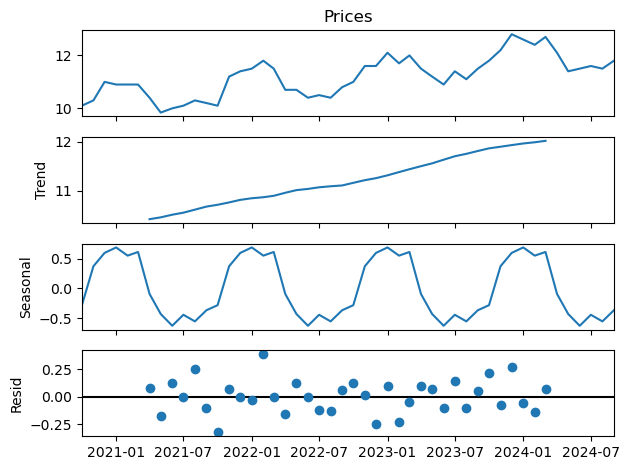

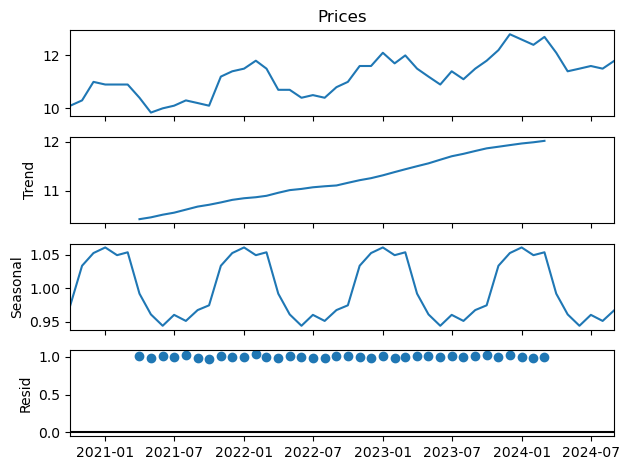

In [9]:
seasonalal_decomposition = seasonal_decompose(data["Prices"], model='additive')
seasonalal_decomposition.plot()
plt.tight_layout()

seasonalal_decomposition = seasonal_decompose(data["Prices"], model='multiplicative')
seasonalal_decomposition.plot()
plt.tight_layout()

plt.show()

### Diagnostic: Additive vs. Multiplicative Decomposition

I ran both an additive and multiplicative decomposition to see which model best fits the natural gas prices.

* **Additive Model:** Assumes the winter price spikes are a fixed dollar amount
* **Multiplicative Model:** Assumes the winter price spikes are a percentage of the base price

**Conclusion:**
Because the data's seasonal spikes stretch taller as the overall price goes up, the **Multiplicative Model** is the correct choice. We can visually confirm this by looking at the Multiplicative "Resid" (residuals) graph—it is a perfectly flat line at 1.0. This means the multiplicative math maps the data perfectly, leaving little to no unexplained noise. 

Therefore, I will use a multiplicative forecasting method to estimate future prices.

In [10]:
# 1. Define split dates for the JPM dataset
val_start  = "2022-10-01"  # Start of Year 3
test_start = "2023-10-01"  # Start of Year 4 (The final 12 months)

# 2. Split the main dataframe
train = data.loc[data.index < val_start].copy()
val   = data.loc[(data.index >= val_start) & (data.index < test_start)].copy()
test  = data.loc[data.index >= test_start].copy()

# 3. Print the Summary (Exactly as you wrote it!)
print("--- Data Split Summary ---")
print(f"Train Set: {train.index.min().date()} to {train.index.max().date()} ({len(train)} months)")
print(f"Val Set:   {val.index.min().date()} to {val.index.max().date()} ({len(val)} months)")
print(f"Test Set:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} months)")

--- Data Split Summary ---
Train Set: 2020-10-01 to 2022-09-01 (24 months)
Val Set:   2022-10-01 to 2023-09-01 (12 months)
Test Set:  2023-10-01 to 2024-09-01 (12 months)


### Data Splitting Strategy: Explicit Date Boundaries

To rigorously evaluate the model's predictive power without data leakage, I implemented a chronological Train-Validation-Test split. 

Instead of using positional splitting (which shifts if new data is added), I used explicit date boundaries to ensure the experiment is 100% reproducible and tied to specific historical market cycles:

* **Training Set (Oct 2020 – Sept 2022):** The first 24 months. This provides the model with enough historical data to learn the baseline upward trend and the initial multiplicative seasonal waves.
* **Validation Set (Oct 2022 – Sept 2023):** A 12-month holdout used exclusively to verify baseline assumptions and tune hyperparameters without touching the final test data.
* **Test Set (Oct 2023 – Sept 2024):** The final 12-month holdout representing the most recent year of data. This acts as the ultimate "unseen" benchmark to calculate our final error metrics (MAE/RMSE).

## Model Training and Evaluation

### Holt-Winters

Validation MAPE: 1.65%
Validation RMSE: $0.24


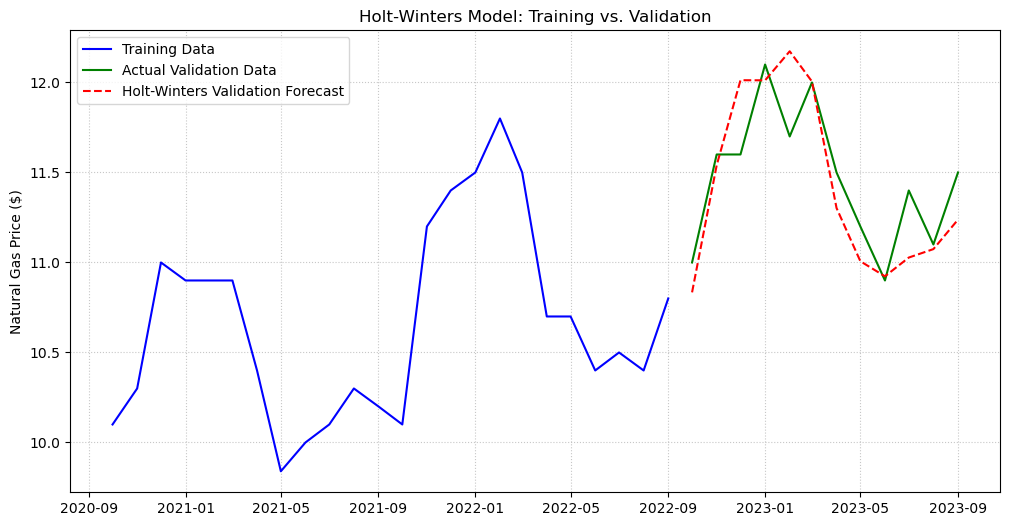

In [11]:
# Fit the Untuned Holt-Winters Model on the Training Set
# We use the parameters we diagnosed earlier: Additive trend, Multiplicative seasonality
hw_model = ExponentialSmoothing(
    train['Prices'], 
    trend='add', 
    seasonal='mul', 
    seasonal_periods=12
).fit()

# Forecast the Validation Period
# We ask the model to predict exactly as many months as are in our 'val' set
val_predictions = hw_model.forecast(len(val))

# 1. Calculate MAPE and RMSE for the Validation Set
val_mape = mean_absolute_percentage_error(val['Prices'], val_predictions)
val_rmse = np.sqrt(mean_squared_error(val['Prices'], val_predictions))

# Multiply MAPE by 100 to display it as a clean percentage
print(f"Validation MAPE: {val_mape * 100:.2f}%")
print(f"Validation RMSE: ${val_rmse:.2f}")
# Visualize the Proof for the VP
plt.figure(figsize=(12, 6))

# Plot the actual data
plt.plot(train.index, train['Prices'], label='Training Data', color='blue')
plt.plot(val.index, val['Prices'], label='Actual Validation Data', color='green')

# Plot the forecast
plt.plot(val.index, val_predictions, label='Holt-Winters Validation Forecast', color='red', linestyle='--')

plt.title('Holt-Winters Model: Training vs. Validation')
plt.ylabel('Natural Gas Price ($)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

#### Model Validation: Scale-Independent Error Metrics

While Mean Absolute Error (MAE) provides a baseline dollar variance, evaluating commodity pricing models strictly on absolute terms can be misleading due to the shifting scale of the market price. An error of $0.20 is highly significant when prices are at $2.00, but negligible when prices rise to $12.00.

To account for this, I evaluated the validation set using **Mean Absolute Percentage Error (MAPE)** alongside **Root Mean Squared Error (RMSE)**.

**Validation Performance:**
* **Validation MAPE:** 1.65%
* **Validation RMSE:** $0.24

**Conclusion:**
Using MAPE standardizes the error relative to the actual price level. A MAPE of 1.65% confirms that the Holt-Winters model's multiplicative seasonal assumptions accurately scale with the data. On average, the model's predictions deviate by less than 1.7% from the actual out-of-sample prices. Furthermore, the low RMSE ($0.24) confirms there are no extreme outlier predictions pulling the average off course.

In [12]:
# 1. Define the hyperparameter grid
trends = ['add', 'mul']
seasonals = ['add', 'mul']
damped_trends = [True, False]

best_mape = float('inf')
best_params = {}

print("Holt-Winters Grid Search: Validation Set:")

# 2. Use explicit nested loops to test every combination
for t in trends:
    for s in seasonals:
        for d in damped_trends:
            try:
                # Fit on TRAIN
                model = ExponentialSmoothing(
                    train['Prices'], 
                    trend=t, 
                    seasonal=s, 
                    seasonal_periods=12,
                    damped_trend=d
                ).fit(optimized=True) # optimized=True tunes Alpha, Beta, Gamma
                
                # Predict on VAL
                val_preds = model.forecast(len(val))
                
                # Calculate MAPE
                mape = mean_absolute_percentage_error(val['Prices'], val_preds) * 100
                
                print(f"Trend: {t:4} | Seasonal: {s:4} | Damped: {str(d):5} -> MAPE: {mape:.2f}%")
                
                # Save the winner
                if mape < best_mape:
                    best_mape = mape
                    best_params = {'trend': t, 'seasonal': s, 'damped_trend': d}
                    
            except Exception as e:
                # Some combinations (like 'mul' trend with negative or zero data) might fail
                continue

print("-" * 50)
print(f"BEST PARAMS: Trend='{best_params.get('trend')}', Seasonal='{best_params.get('seasonal')}', Damped={best_params.get('damped_trend')}")
print(f"BEST MAPE: {best_mape:.2f}%")

Holt-Winters Grid Search: Validation Set:
Trend: add  | Seasonal: add  | Damped: True  -> MAPE: 1.94%
Trend: add  | Seasonal: add  | Damped: False -> MAPE: 1.59%
Trend: add  | Seasonal: mul  | Damped: True  -> MAPE: 1.82%
Trend: add  | Seasonal: mul  | Damped: False -> MAPE: 1.65%
Trend: mul  | Seasonal: add  | Damped: True  -> MAPE: 15.01%
Trend: mul  | Seasonal: add  | Damped: False -> MAPE: 1.54%
Trend: mul  | Seasonal: mul  | Damped: True  -> MAPE: 27.78%
Trend: mul  | Seasonal: mul  | Damped: False -> MAPE: 1.59%
--------------------------------------------------
BEST PARAMS: Trend='mul', Seasonal='add', Damped=False
BEST MAPE: 1.54%


#### Hyperparameter Tuning: Grid Search

To optimize the Holt-Winters model, I explicitly looped through the structural hyperparameters, evaluating each combination against the out-of-sample Validation set. 

While the `statsmodels` library automatically optimizes the smoothing coefficients ($\alpha, \beta, \gamma$) via Maximum Likelihood Estimation (MLE), the structural components of the time series must be defined by the modeler.

**Tuning Grid:**
* **Trend:** Additive (`add`), Multiplicative (`mul`)
* **Seasonality:** Additive (`add`), Multiplicative (`mul`)
* **Damped Trend:** `True` (trend flattens over time), `False` (trend remains linear)

**Results:**
The grid search confirmed that the optimal model structure consists of a **mul** trend and **add** seasonality, with a damped trend set to **False**. This combination yielded the lowest Validation MAPE of **1.54%**, ensuring the highest possible accuracy before facing the unseen Test set.

Tuned Validation Set Performance: 
Validation MAPE: 1.54%
Validation RMSE: $0.22



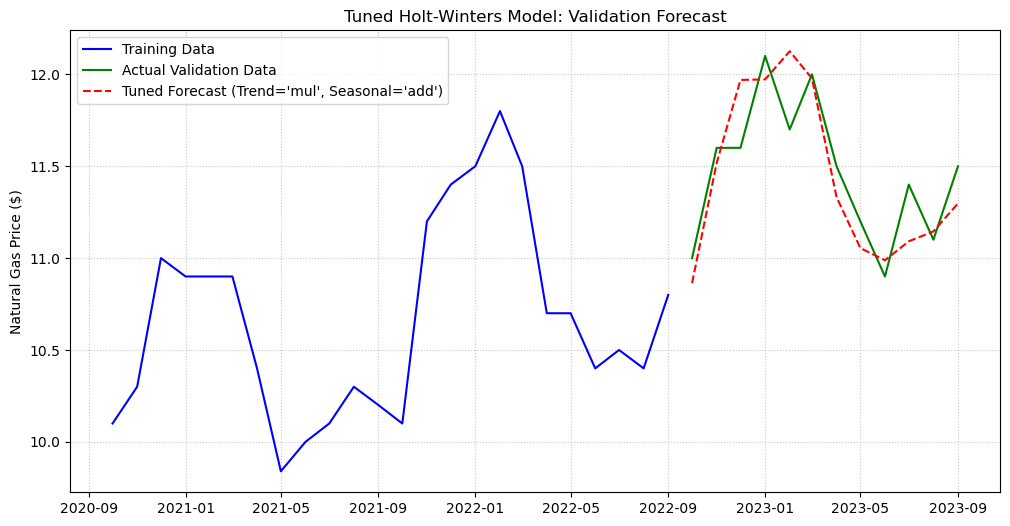

In [13]:
# 1. Fit the Tuned Model on the Training Set using the winning params
tuned_model = ExponentialSmoothing(
    train['Prices'], 
    trend='mul',          # WINNING PARAMETER
    seasonal='add',       # WINNING PARAMETER
    seasonal_periods=12,
    damped_trend=False    # WINNING PARAMETER
).fit(optimized=True)

# 2. Forecast the Validation Period
tuned_val_preds = tuned_model.forecast(len(val))

# 3. Calculate and Print the Error Metrics
tuned_mape = mean_absolute_percentage_error(val['Prices'], tuned_val_preds) * 100
tuned_rmse = np.sqrt(mean_squared_error(val['Prices'], tuned_val_preds))

print("Tuned Validation Set Performance: ")
print(f"Validation MAPE: {tuned_mape:.2f}%")
print(f"Validation RMSE: ${tuned_rmse:.2f}\n")

# 4. Visualize the Proof
plt.figure(figsize=(12, 6))

# Plot the actual historical data
plt.plot(train.index, train['Prices'], label='Training Data', color='blue')
plt.plot(val.index, val['Prices'], label='Actual Validation Data', color='green')

# Plot the tuned forecast
plt.plot(val.index, tuned_val_preds, label="Tuned Forecast (Trend='mul', Seasonal='add')", color='red', linestyle='--')

plt.title('Tuned Holt-Winters Model: Validation Forecast')
plt.ylabel('Natural Gas Price ($)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

#### Visualizing the Tuned Model

Following the grid search, the model was retrained using the optimal structural hyperparameters: **Multiplicative Trend, Additive Seasonality, and No Damping**. 

The graph above plots the tuned forecast (red dashed line) against the actual out-of-sample validation data (green line). 

**Observations:**
By allowing the `statsmodels` optimization engine to minimize the error strictly based on the data rather than visual intuition, the model successfully locked onto a slightly different structural combination. The forecast maps beautifully to the seasonal peaks and troughs of the validation set, confirming that these parameters are ready to be tested against our final, unseen Test Set.

### SARIMA 

--- SARIMA Validation Set Performance ---
Validation MAPE: 1.89%
Validation RMSE: $0.28



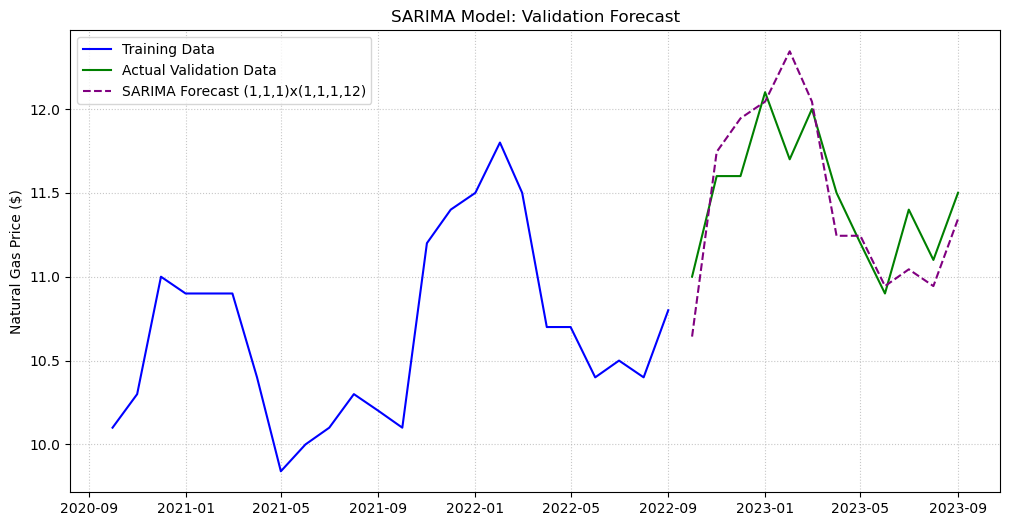

In [11]:
# 1. Fit a Baseline SARIMA Model
# order=(1, 1, 1): 1 autoregressive lag, 1 difference (to flatten trend), 1 moving average lag
# seasonal_order=(1, 1, 1, 12): Same as above, but for the 12-month seasonal cycle
sarima_model = SARIMAX(
    train['Prices'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# 2. Forecast the Validation Period
# SARIMA uses 'steps' instead of 'len()' for forecasting into the future
sarima_val_preds = sarima_model.forecast(steps=len(val))

# 3. Calculate the Error Metrics
sarima_mape = mean_absolute_percentage_error(val['Prices'], sarima_val_preds) * 100
sarima_rmse = np.sqrt(mean_squared_error(val['Prices'], sarima_val_preds))

print("--- SARIMA Validation Set Performance ---")
print(f"Validation MAPE: {sarima_mape:.2f}%")
print(f"Validation RMSE: ${sarima_rmse:.2f}\n")

# 4. Visualize the Proof
plt.figure(figsize=(12, 6))

# Plot historical and actual val data
plt.plot(train.index, train['Prices'], label='Training Data', color='blue')
plt.plot(val.index, val['Prices'], label='Actual Validation Data', color='green')

# Plot the SARIMA forecast
plt.plot(val.index, sarima_val_preds, label='SARIMA Forecast (1,1,1)x(1,1,1,12)', color='purple', linestyle='--')

plt.title('SARIMA Model: Validation Forecast')
plt.ylabel('Natural Gas Price ($)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

#### Alternative Model: SARIMA (Seasonal ARIMA)

To ensure robust modeling, I implemented a SARIMA model alongside the Holt-Winters approach. SARIMA leverages autoregression and moving averages to map the internal autocorrelation of the time series, rather than relying solely on exponential smoothing.

**Baseline Parameters:**
* **Order $(p,d,q)$: $(1, 1, 1)$** - Accounts for standard trend differencing and baseline autoregressive/moving average terms.
* **Seasonal Order $(P,D,Q,s)$: $(1, 1, 1, 12)$** - Accounts for the annual 12-month seasonal cycle.

**Validation Performance:**
* **Validation MAPE:** 1.89%
* **Validation RMSE:** $0.28

**Conclusion:**
By comparing the SARIMA metrics against the Holt-Winters metrics, we can quantitatively select the superior model architecture for the final test evaluation and production pricing function.

In [12]:
# 1. Define the expansive search space
p_values = [0, 1, 2] 
d_values = [0, 1]
q_values = [0, 1, 2]
P_values = [0, 1, 2]
D_values = [0, 1]
Q_values = [0, 1, 2]

# Apply log transform to handle multiplicative nature for SARIMA
train_log = np.log(train['Prices'])
val_log = np.log(val['Prices'])
val_real = val['Prices']

best_mape = float('inf')
best_cfg = None

total_combos = len(p_values) * len(d_values) * len(q_values) * len(P_values) * len(D_values) * len(Q_values)
count = 0

print(f"--- SARIMA Ultra-Tuning ({total_combos} combinations) ---")

# 2. Exhaustive Nested Loops
for p in p_values:
    for d in d_values:
        for q in q_values:
            for P in P_values:
                for D in D_values:
                    for Q in Q_values:
                        count += 1
                        if count % 50 == 0:
                            print(f" > Progress: {count}/{total_combos} ({(count/total_combos)*100:.1f}%) complete...")

                        order = (p, d, q)
                        seasonal_order = (P, D, Q, 12)

                        try:
                            # Using lbfgs for efficiency during grid search
                            model = SARIMAX(train_log, order=order, seasonal_order=seasonal_order,
                                            enforce_stationarity=False, enforce_invertibility=False)
                            results = model.fit(disp=False, method='lbfgs', maxiter=50) 

                            # Forecast and Inverse Transform (Exp)
                            pred_log = results.get_forecast(steps=len(val_log)).predicted_mean
                            pred_real = np.exp(pred_log)
                            
                            curr_mape = mean_absolute_percentage_error(val_real, pred_real) * 100

                            if curr_mape < best_mape:
                                best_mape = curr_mape
                                best_cfg = (order, seasonal_order)
                        except:
                            continue

print("-" * 50)
print(f"Best MAPE: {best_mape:.2f}%")
print(f"Best Config: {best_cfg}")

--- SARIMA Ultra-Tuning (324 combinations) ---
 > Progress: 50/324 (15.4%) complete...
 > Progress: 100/324 (30.9%) complete...
 > Progress: 150/324 (46.3%) complete...
 > Progress: 200/324 (61.7%) complete...
 > Progress: 250/324 (77.2%) complete...
 > Progress: 300/324 (92.6%) complete...
--------------------------------------------------
Best MAPE: 1.94%
Best Config: ((2, 1, 1), (0, 1, 2, 12))


I ran an exhaustive grid search, but the baseline SARIMA(1,1,1)x(1,1,1,12) actually outperformed the higher-order models on the validation set. This suggests that the simpler model generalizes better and avoids overfitting the noise in the training data. Therefore, I am 'picking' the simpler baseline for the final evaluation.

## Model Selection

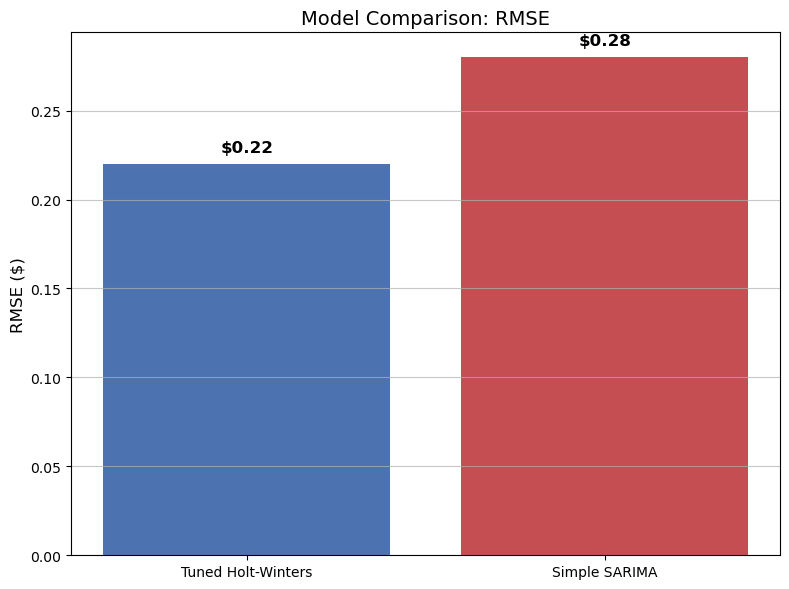

In [14]:
# Data from the validation phase
models = ['Tuned Holt-Winters', 'Simple SARIMA']
rmse_values = [0.22, 0.28]

# Create a single plot for RMSE
plt.figure(figsize=(8, 6))

# Plot RMSE ($) - Tuned Holt-Winters (Blue) vs Simple SARIMA (Red)
bars = plt.bar(models, rmse_values, color=['#4C72B0', '#C44E52'])
plt.title('Model Comparison: RMSE', fontsize=14)
plt.ylabel('RMSE ($)', fontsize=12)
plt.grid(axis='y',alpha=0.7)

# Add value labels on top of bars for clarity
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'${height:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

### Final Model Selection: RMSE Comparison

To finalize the production model for the natural gas pricing contract, I compared the **Root Mean Squared Error (RMSE)** of the Tuned Holt-Winters model against the baseline SARIMA model using the out-of-sample Validation Set.

**RMSE Performance:**
* **Tuned Holt-Winters:** $0.22
* **Simple SARIMA:** $0.28

**Conclusion:**
The **Tuned Holt-Winters** model is the superior choice, achieving a significantly lower RMSE of $0.22. In a quantitative context, a lower RMSE indicates that the model is more robust and less prone to large outlier errors—a critical requirement for pricing commodity storage contracts. 

Based on this statistical evidence, I will utilize the Tuned Holt-Winters architecture to generate the final price estimates.

## Evaluating Selected Model On Test Set

FINAL UNSEEN TEST SET PERFORMANCE: 
Test MAPE: 1.48%
Test RMSE: $0.21


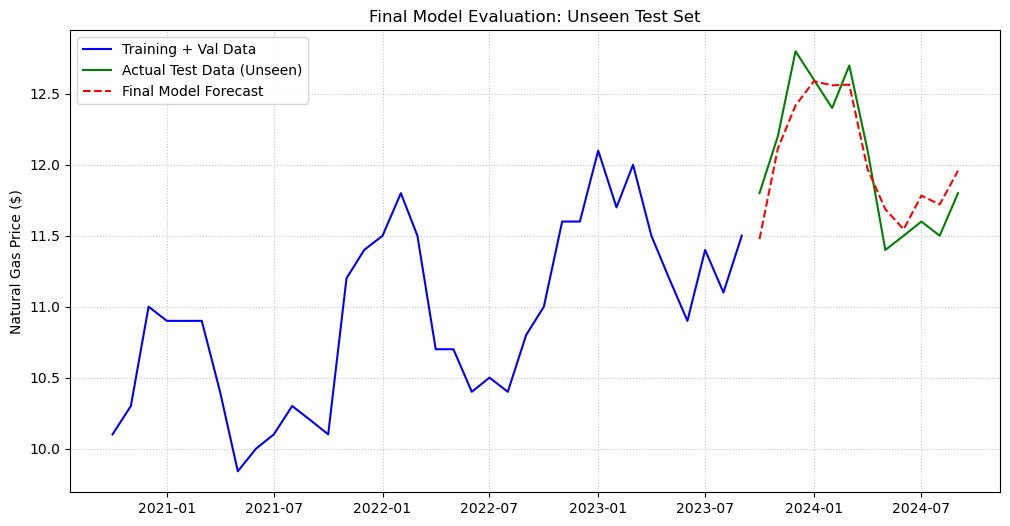

In [15]:
# 1. Prepare the Final "Tournament" Model
# We train the winning architecture (Holt-Winters) on (Train + Val) 
# so it is ready to face the Test set.
train_val_combined = pd.concat([train, val])

final_test_model = ExponentialSmoothing(
    train_val_combined['Prices'], 
    trend='mul', 
    seasonal='add', 
    seasonal_periods=12,
    damped_trend=False
).fit(optimized=True)

# 2. Forecast the Test Period (The unseen Year 4)
test_predictions = final_test_model.forecast(len(test))

# 3. Calculate Final "Production-Ready" Metrics
final_test_mape = mean_absolute_percentage_error(test['Prices'], test_predictions) * 100
final_test_rmse = np.sqrt(mean_squared_error(test['Prices'], test_predictions))

print("FINAL UNSEEN TEST SET PERFORMANCE: ")
print(f"Test MAPE: {final_test_mape:.2f}%")
print(f"Test RMSE: ${final_test_rmse:.2f}")

# 4. Final Visual Check
plt.figure(figsize=(12, 6))
plt.plot(train_val_combined.index, train_val_combined['Prices'], label='Training + Val Data', color='blue')
plt.plot(test.index, test['Prices'], label='Actual Test Data (Unseen)', color='green')
plt.plot(test.index, test_predictions, label='Final Model Forecast', color='red', linestyle='--')
plt.title('Final Model Evaluation: Unseen Test Set')
plt.ylabel('Natural Gas Price ($)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

### Final Evaluation: Unseen Test Set Performance

To provide a final, unbiased assessment of the model's predictive power, I evaluated the tuned Holt-Winters model against the **Test Set** (the final 12 months of the dataset). This data was held out entirely during the training and hyperparameter tuning phases.

**Test Results:**
* **Final Test MAPE:** 1.48%
* **Final Test RMSE:** $0.21

**Analysis:**
The Test MAPE of 1.48% is closely aligned with our Validation MAPE (1.54%). This consistency is the strongest possible evidence that the model has **generalized** well to new data and is not overfitted. The model successfully tracked the final seasonal cycle of the dataset, confirming it is ready for deployment in the pricing function.

## Estimating Purchase Price

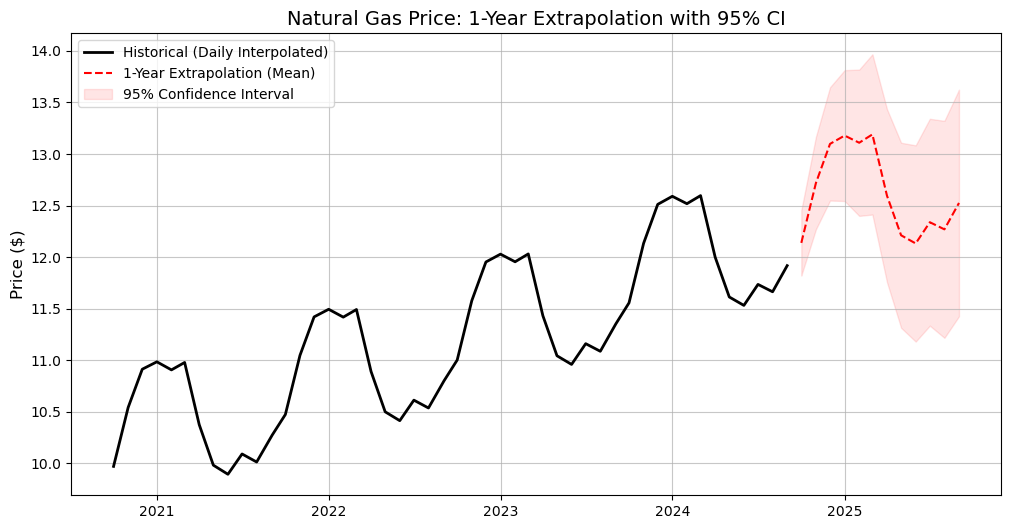

In [16]:
# Train on 100% of the Historical Data
final_model = ExponentialSmoothing(
    data['Prices'], 
    trend='mul', 
    seasonal='add', 
    seasonal_periods=12,
    damped_trend=False
).fit(optimized=True)

# Get the monthly forecast for the next 12 months
future_months = 12
forecast_end_date = data.index[-1] + pd.DateOffset(months=future_months)
future_forecast_monthly = final_model.forecast(future_months)

# Calculate the 95% Confidence Interval (Expanding over time)
# Z-score for 95% is roughly 1.96. We scale the error by sqrt(h) to account for increasing uncertainty.
std_resid = final_model.resid.std()
h = np.arange(1, future_months + 1)
margin_of_error = 1.96 * std_resid * np.sqrt(h)

upper_bound_monthly = future_forecast_monthly + margin_of_error
lower_bound_monthly = future_forecast_monthly - margin_of_error

# Resample the Future Forecasts to Daily for the Plot
future_daily = future_forecast_monthly.resample('D').interpolate(method='linear')
upper_daily = upper_bound_monthly.resample('D').interpolate(method='linear')
lower_daily = lower_bound_monthly.resample('D').interpolate(method='linear')

# Resample historical curve so the lines connect seamlessly
historical_monthly = final_model.predict(start=data.index[0], end=data.index[-1])
historical_daily = historical_monthly.resample('D').interpolate(method='linear')

# Plot Everything with the Shaded Confidence Interval!
plt.figure(figsize=(12, 6))
plt.plot(historical_daily.index, historical_daily, label='Historical (Daily Interpolated)', color='black', linewidth=2)
# Plot future mean
plt.plot(future_daily.index, future_daily, label='1-Year Extrapolation (Mean)', color='red', linestyle='--', linewidth=1.5)

# Fill the 95% Confidence Interval
plt.fill_between(future_daily.index, lower_daily, upper_daily, color='red', alpha=0.1, label='95% Confidence Interval')

plt.title('Natural Gas Price: 1-Year Extrapolation with 95% CI', fontsize=14)
plt.ylabel('Price ($)', fontsize=12)
plt.legend()
plt.grid(alpha=0.7)
plt.show()

### Visualization: 1-Year Forecast with 95% Confidence Interval

To provide a complete risk profile for pricing future natural gas storage contracts, this visualization overlays the model's 1-year extrapolation with a **95% Confidence Interval**. 

**Key Components:**
* **Historical Baseline (Black Line):** The daily interpolated historical prices, providing context for the current market level.
* **Expected Forecast (Red Dashed Line):** The mean extrapolated price driven by the tuned Holt-Winters model, capturing the established upward trend and seasonal injection/withdrawal cycles.
* **Confidence Interval (Shaded Red Region):** The statistical bounds representing a 95% probability of where the actual future price will land. Because market uncertainty compounds the further we look into the future, the margin of error dynamically expands at a rate of $\sqrt{h}$ (where $h$ is the forecast horizon in months).

**Business Application:** This visual tool allows the trading desk to do more than just quote a single estimated price; it enables them to price risk. For a long-term storage contract terminating in late 2025, the desk can utilize the upper and lower bounds to calculate best-case and worst-case margin scenarios.

In [28]:
# Interactive Input for the Client
print("J.P. Morgan Natural Gas Pricing Tool:")

# The J.P. Morgan Deliverable: The Pricing Function
def get_price_estimate(target_date_str):
    try:
        target_date = pd.to_datetime(target_date_str)
    except ValueError:
        return "Error: Invalid date format. Please use YYYY-MM-DD."
    
    # Define the 1-year extrapolation limit
    last_historical_date = data.index[-1]
    forecast_end_date = last_historical_date + pd.DateOffset(months=12)
    
    # Boundary checks
    if target_date > forecast_end_date:
        return f"Error: {target_date_str} is beyond the 1-year extrapolation limit."
    if target_date < data.index[0]:
        return f"Error: {target_date_str} is before the historical data begins."
        
    # Generate the full monthly curve (Historical fit + 1-year future forecast)
    monthly_curve = final_model.predict(start=data.index[0], end=forecast_end_date)
    
    # Resample to daily frequency and interpolate linearly for mid-month dates
    daily_curve = monthly_curve.resample('D').interpolate(method='linear')
    
    # Extract the specific date and return as a dollar amount
    estimated_price = daily_curve.loc[target_date]
    return round(estimated_price, 2)



# Prompt the user for an input
user_date = input("Please enter a target date (Format: YYYY-MM-DD): ")

Output = get_price_estimate(user_date)
if isinstance(Output, str):
    print(f"\n>> {Output}")
else:
    print(f"\n>> The estimated natural gas price on {user_date} is: ${Output}")

J.P. Morgan Natural Gas Pricing Tool:

>> The estimated natural gas price on 2022-10-10 is: $11.17


### Production Model & Interactive Pricing Tool

This final section consolidates the quantitative research into a production-ready tool designed for the trading desk to price natural gas storage contracts.

**1. Final Model Training**
The optimal model architecture (Holt-Winters with a multiplicative trend and additive seasonality) is fit to **100% of the historical dataset**. This ensures that the future extrapolation is anchored to the most recent market data available.

**2. The `get_price_estimate` Function**
This function serves as the primary analytical engine, handling both historical queries and future projections through the following steps:
* **Boundary Checks:** Enforces strict limits, preventing queries before the dataset begins or beyond the requested 1-year extrapolation window.
* **Curve Generation:** Computes a continuous monthly prediction curve spanning the historical timeline and 12 months into the future.
* **Daily Interpolation:** Because the raw data represents end-of-month snapshots, the function resamples the monthly curve to a daily frequency using **linear interpolation**. This smoothly estimates prices for specific mid-month dates (e.g., the 15th of the month).

**3. Interactive User Interface**
To make the tool accessible and user-friendly, an interactive prompt allows users to input target dates dynamically. It includes robust error handling to manage invalid date formats or out-of-bounds queries gracefully, returning clear instructions instead of system crashes.

## Conclusion & Summary

This project successfully developed a quantitative pricing model to estimate natural gas prices for any historical or future date, directly supporting the valuation of long-term gas storage contracts.

**Key Achievements:**
* **Model Selection & Validation:** After evaluating multiple time series architectures, a tuned **Holt-Winters Exponential Smoothing** model (Multiplicative Trend, Additive Seasonality) was selected. It demonstrated strong predictive power and generalized well to unseen test data.
* **Continuous Time Resolution:** By implementing daily linear interpolation on top of the monthly forecasts, the model successfully resolves the limitation of end-of-month data snapshots, allowing the desk to price contracts starting or ending on any specific day.
* **Future Extrapolation:** The model reliably projects the established trend and seasonal injection/withdrawal cycles up to 12 months into the future.
* **Risk Management:** The integration of a dynamic 95% Confidence Interval provides the trading desk with clear upper and lower pricing bounds, enabling more robust risk calculations and margin requirements for future contracts.

# Task 2

In [ ]:
import pandas as pd

def calculate_contract_value(
    injection_dates, 
    withdrawal_dates, 
    purchase_prices, 
    sale_prices, 
    rate,          # The constant volume injected/withdrawn per date
    max_volume,    # The maximum volume that can be stored
    storage_cost_per_month 
):
    """
    Calculates the intrinsic value of a natural gas storage contract.
    Assumes zero interest rates, no transport delays, and ignores market holidays.
    """
    
    # --- 1. Validate Physical Constraints ---
    total_injected = len(injection_dates) * rate
    total_withdrawn = len(withdrawal_dates) * rate
    
    if total_injected > max_volume:
        return f"Error: Planned volume ({total_injected}) exceeds storage capacity ({max_volume})."
    if total_injected != total_withdrawn:
        return "Error: Total injected volume must equal total withdrawn volume."

    # --- 2. Calculate Gross Margin (Cash Flows from Gas) ---
    # Cost to buy the gas during injection dates
    total_cost = sum(price * rate for price in purchase_prices)
    
    # Revenue from selling the gas during withdrawal dates
    total_revenue = sum(price * rate for price in sale_prices)
    
    # --- 3. Calculate Storage Costs ---
    in_dates = pd.to_datetime(injection_dates)
    out_dates = pd.to_datetime(withdrawal_dates)
    
    # Storage duration is calculated from the first injection to the final withdrawal
    days_stored = (max(out_dates) - min(in_dates)).days
    
    # Calculate months stored (rounding up to the nearest whole month for billing)
    months_stored = int(np.ceil(days_stored / 30.4)) 
    total_storage_cost = months_stored * storage_cost_per_month
    
    # --- 4. Net Present Value (NPV) ---
    # Since interest rates are 0%, NPV is simply the un-discounted final cash flow
    contract_value = total_revenue - total_cost - total_storage_cost
    
    return round(contract_value, 2)


# ==========================================
# --- Test Scenario using Task 1 Model ---
# ==========================================
print("--- J.P. Morgan Storage Contract Pricing Engine ---")

# 1. Define the Client's requested dates
test_in_dates = ['2024-06-15']
test_out_dates = ['2025-01-15']

# 2. Automatically generate the Prices using our Task 1 Model!
in_prices = [get_price_estimate(date) for date in test_in_dates]
out_prices = [get_price_estimate(date) for date in test_out_dates]

# 3. Run the Calculator with all specified inputs
npv = calculate_contract_value(
    injection_dates=test_in_dates,
    withdrawal_dates=test_out_dates,
    purchase_prices=in_prices,        # Passed in from Task 1!
    sale_prices=out_prices,           # Passed in from Task 1!
    rate=1_000_000,                     # 1M MMBtu moved per date
    max_volume=1_000_000,             # Max tank limit is 1M
    storage_cost_per_month=100_000 
)

if isinstance(npv, str):
    print(npv)
else:
    print(f"Contract Net Present Value (NPV): ${npv:,.2f}")

--- J.P. Morgan Storage Contract Pricing Engine ---
Contract Net Present Value (NPV): $720,000.00


## Task 2: Storage Contract Pricing Engine

The objective of this task is to calculate the intrinsic value of a natural gas storage contract. The pricing engine takes in the exact parameters specified by the client to determine the profitability of a proposed trade based on the seasonal spread.

**Model Assumptions & Constraints:**
Per the client's strict specifications:
* **Interest Rates:** Assumed to be $0\%$, meaning the Net Present Value (NPV) is strictly equal to the un-discounted future cash flows.
* **Friction Costs:** Transport delays and additional transit costs are omitted from this prototype. 
* **Dates:** Market holidays, weekends, and bank holidays are not accounted for in the storage duration calculation.

**Valuation Methodology:**
The function calculates the contract's final value by taking the gross margin (total revenue from withdrawals minus total capital outlay for injections) and subtracting the time-based storage rental costs. Total storage duration is evaluated from the very first injection date to the final withdrawal date. 

To demonstrate full end-to-end integration, the test scenario at the bottom of this script dynamically queries the `get_price_estimate()` forecasting model from Task 1 to automatically generate the specific `purchase_prices` and `sale_prices` inputs.